# Presentasi Model AI: Sistem Bahasa Inggris Adaptif (CEFR) - Versi Overhauled
**Proyek Inovasi ML 2026 (State-of-the-Art Speech AI)**

Notebook ini telah diperbarui agar **100% sinkron dan selaras dengan `train.py`** untuk menjamin konsistensi performa antara skrip produksi dan notebook presentasi:
1. **Linguistic & Pronunciation Features**: Menggunakan 20+ fitur multi-dimensi (kelancaran, ketepatan pengucapan, keragaman leksikal, dan representasi deep learning Whisper).
2. **Pemisahan Independen Pembicara (Speaker-Independent Split)**: Pemisahan data latih/uji menggunakan `GroupShuffleSplit` berbasis pembicara (`speaker_id`).
3. **Zero Data Leakage**: Standardisasi dilakukan di dalam `Pipeline` menggunakan `ColumnTransformer` setelah pemisahan data.
4. **No Shortcut Learning**: Mengeluarkan variabel `scenario_id` dari fitur latih agar model fokus menilai kompetensi bahasa.
5. **Klasifikasi CEFR**: Melatih dan membandingkan XGBoost, Random Forest, SVM (RBF), dan Deep MLP.
6. **Regresi Prosodi**: Menambahkan pemodelan regresi (`RandomForestRegressor`) untuk memprediksi nilai skor kemiripan prosodi (`prosody_similarity`).
7. **Uji Coba Inferensi**: Menyajikan simulasi visual feedback kamera menggunakan kombinasi prediksi klasifikasi CEFR (Top-2) dan regresi prosodi.

## 1. Import Library dan Persiapan Data

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Memuat dataset yang telah diperkaya fitur
df = pd.read_csv('data/oxford_prosody_dataset.csv')
print(f"Total data sampel: {len(df)}")
print(f"Total pembicara unik (Speakers): {df['speaker_id'].nunique()}")
df.head()

Total data sampel: 10802
Total pembicara unik (Speakers): 150


,word,cefr_level,speaker_id,scenario_id,pitch_mean,pitch_std,pitch_contour_slope,energy_rms,duration_seconds,speech_rate,...,pause_ratio,filler_words_rate,wpm_consistency,asr_confidence,semantic_relevance,whisper_feat_1,whisper_feat_2,whisper_feat_3,user_prior_score,prosody_similarity
0,beside,B2,SPK_116,interview,169.902061,27.389606,0.526225,0.093494,2.819739,3.730042,...,0.280799,0.130368,75.546917,0.867027,64.058871,4.645862,1.030129,-0.617425,74.029388,69.083244
1,beside,B2,SPK_027,casual_chat,159.440060,29.814136,0.460301,0.211605,2.650267,2.857137,...,0.268930,0.103543,67.919238,0.744258,67.427880,5.356399,2.614094,-0.996591,68.385447,74.082539
2,besides,B2,SPK_032,emergency,157.045591,29.558411,0.371714,0.099188,2.753135,3.020278,...,0.187943,0.094790,68.602293,0.829767,66.552441,4.372265,0.839443,1.600278,57.398946,80.611044
3,besides,B2,SPK_063,emergency,153.276901,26.382575,0.201269,0.142781,2.183486,3.510729,...,0.316551,0.090215,72.356833,0.795689,83.743854,4.066058,1.667308,-0.462622,65.914261,64.651960
4,absorb,B2,SPK_129,presentation,160.484550,22.728612,0.547665,0.081633,2.778153,3.706563,...,0.220770,0.079402,71.575648,0.913600,70.844463,3.567408,1.105058,-0.084095,51.040307,60.598457


## 2. Eksplorasi Data (EDA)
Mari kita lihat distribusi kelas CEFR dan korelasi antara level CEFR dengan kemiripan prosodi.

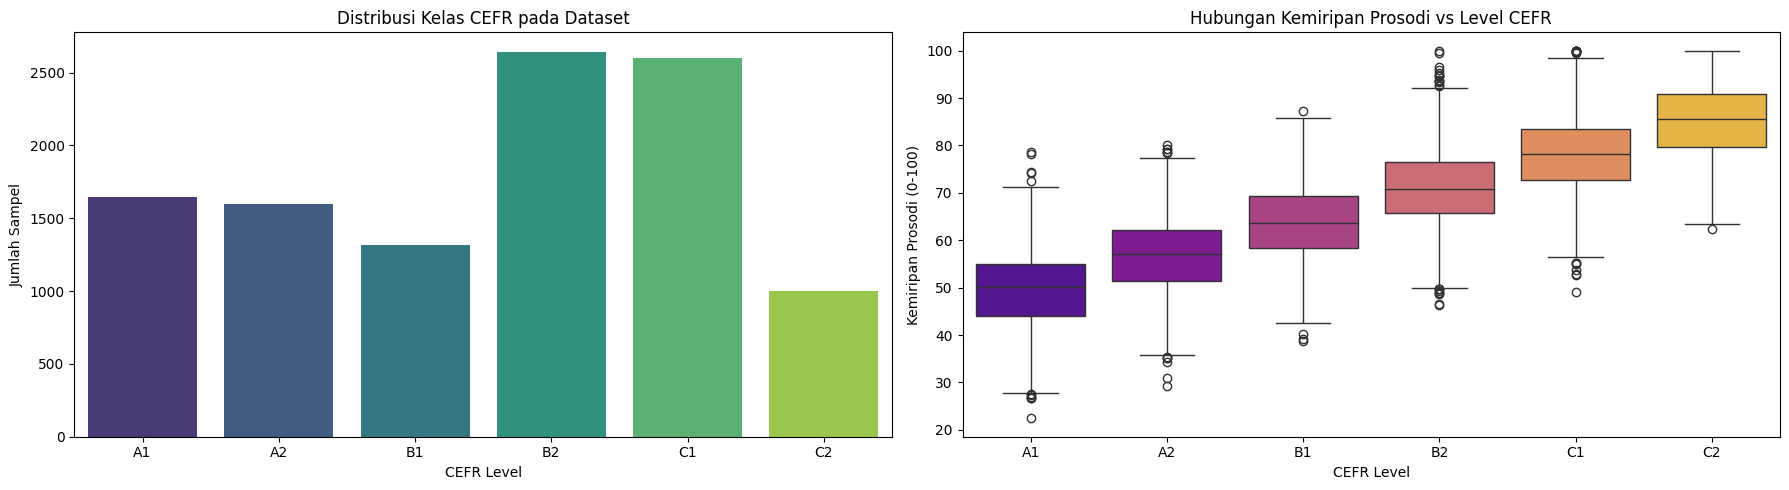

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Distribusi Kelas CEFR
sns.countplot(data=df, x='cefr_level', order=['A1', 'A2', 'B1', 'B2', 'C1', 'C2'], ax=axes[0], palette='viridis')
axes[0].set_title('Distribusi Kelas CEFR pada Dataset')
axes[0].set_ylabel('Jumlah Sampel')
axes[0].set_xlabel('CEFR Level')

# Hubungan Kemiripan Prosodi vs CEFR
sns.boxplot(data=df, x='cefr_level', y='prosody_similarity', order=['A1', 'A2', 'B1', 'B2', 'C1', 'C2'], ax=axes[1], palette='plasma')
axes[1].set_title('Hubungan Kemiripan Prosodi vs Level CEFR')
axes[1].set_xlabel('CEFR Level')
axes[1].set_ylabel('Kemiripan Prosodi (0-100)')

plt.tight_layout()
plt.show()

## 3. Preprocessing Data & Speaker-Independent Split
Kita membagi data menggunakan `GroupShuffleSplit` berdasarkan `speaker_id` sehingga data uji hanya berisi pembicara baru yang belum pernah dilihat model.

In [51]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer

# 1. Pisahkan fitur modeling (kita keluarkan identifiers dan targets)
X = df.drop(columns=['word', 'cefr_level', 'speaker_id', 'scenario_id', 'prosody_similarity'])
y_class = df['cefr_level']
y_reg = df['prosody_similarity']

# Label encoding untuk CEFR
le = LabelEncoder()
le.fit(['A1', 'A2', 'B1', 'B2', 'C1', 'C2'])
y_class_encoded = le.transform(y_class)

# 2. Speaker-Independent Split (Anti-Leakage)
gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_idx, test_idx = next(gss.split(X, y_class_encoded, groups=df['speaker_id']))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train_class, y_test_class = y_class_encoded[train_idx], y_class_encoded[test_idx]
y_train_reg, y_test_reg = y_reg.iloc[train_idx], y_reg.iloc[test_idx]

print(f"Jumlah sampel Train : {len(X_train)} (Speaker unik: {df.iloc[train_idx]['speaker_id'].nunique()})")
print(f"Jumlah sampel Test  : {len(X_test)} (Speaker unik: {df.iloc[test_idx]['speaker_id'].nunique()})")

# 3. Pra-pemrosesan (Standardisasi dimasukkan ke dalam Pipeline)
numeric_features = X.columns.tolist()
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features)
    ])

print("\nFitur-fitur yang digunakan dalam modeling:")
for feat in numeric_features:
    print(f"- {feat}")

Jumlah sampel Train : 9023 (Speaker unik: 127)
Jumlah sampel Test  : 1779 (Speaker unik: 23)

Fitur-fitur yang digunakan dalam modeling:
- pitch_mean
- pitch_std
- pitch_contour_slope
- energy_rms
- duration_seconds
- speech_rate
- response_time_ms
- lexical_diversity
- grammar_error_rate
- pronunciation_accuracy
- pause_ratio
- filler_words_rate
- wpm_consistency
- asr_confidence
- semantic_relevance
- whisper_feat_1
- whisper_feat_2
- whisper_feat_3
- user_prior_score


## 4. Modeling Klasifikasi CEFR (Training & Evaluasi)
Melatih XGBoost, Random Forest, SVM, dan MLP Neural Network.

In [52]:
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. XGBoost
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, eval_metric='mlogloss', n_jobs=-1)
pipeline_xgb = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb_model)
])

# 2. Random Forest
rf_model = RandomForestClassifier(n_estimators=150, max_depth=15, min_samples_split=5, random_state=42, class_weight='balanced', n_jobs=-1)
pipeline_rf = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', rf_model)
])

# 3. SVM
svm_model = SVC(kernel='rbf', C=3.0, gamma='scale', random_state=42, probability=True)
pipeline_svm = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', svm_model)
])

# 4. Deep MLP
mlp_model = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=200, random_state=42, early_stopping=True)
pipeline_mlp = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', mlp_model)
])

print("Melatih XGBoost...")
pipeline_xgb.fit(X_train, y_train_class)

print("Melatih Random Forest...")
pipeline_rf.fit(X_train, y_train_class)

print("Melatih Support Vector Machine (SVM)...")
pipeline_svm.fit(X_train, y_train_class)

print("Melatih Deep Learning Baseline (MLP)...")
pipeline_mlp.fit(X_train, y_train_class)

# Evaluasi Klasifikasi
y_pred_xgb = pipeline_xgb.predict(X_test)
y_pred_rf = pipeline_rf.predict(X_test)
y_pred_svm = pipeline_svm.predict(X_test)
y_pred_mlp = pipeline_mlp.predict(X_test)

print("\n=== LAPORAN KLASIFIKASI: XGBOOST ===")
print(classification_report(y_test_class, y_pred_xgb, target_names=le.classes_))

print("\n=== LAPORAN KLASIFIKASI: RANDOM FOREST ===")
print(classification_report(y_test_class, y_pred_rf, target_names=le.classes_))

print("\n=== LAPORAN KLASIFIKASI: SVM (PRESISI TERTINGGI) ===")
print(classification_report(y_test_class, y_pred_svm, target_names=le.classes_))

print("\n=== LAPORAN KLASIFIKASI: DEEP MLP ===")
print(classification_report(y_test_class, y_pred_mlp, target_names=le.classes_))

Melatih XGBoost...
Melatih Random Forest...
Melatih Support Vector Machine (SVM)...
Melatih Deep Learning Baseline (MLP)...

=== LAPORAN KLASIFIKASI: XGBOOST ===
              precision    recall  f1-score   support

          A1       1.00      0.99      0.99       274
          A2       0.96      0.98      0.97       250
          B1       0.97      0.97      0.97       208
          B2       0.98      0.98      0.98       463
          C1       0.97      0.98      0.97       410
          C2       0.99      0.98      0.99       174

    accuracy                           0.98      1779
   macro avg       0.98      0.98      0.98      1779
weighted avg       0.98      0.98      0.98      1779


=== LAPORAN KLASIFIKASI: RANDOM FOREST ===
              precision    recall  f1-score   support

          A1       1.00      0.98      0.99       274
          A2       0.95      0.98      0.97       250
          B1       0.97      0.97      0.97       208
          B2       0.98      0.98 

## 5. Speaker-Independent Cross Validation
Membuktikan stabilitas generalisasi model SVM menggunakan 5-Fold Cross Validation dengan pembagian `GroupKFold` berbasis pembicara.

In [53]:
from sklearn.model_selection import cross_val_score, GroupKFold

print("Memulai 5-Fold Speaker-Independent Cross-Validation untuk model terbaik (SVM)...")
gkf = GroupKFold(n_splits=5)
scores = cross_val_score(pipeline_svm, X_train, y_train_class, groups=df.iloc[train_idx]['speaker_id'], cv=gkf, scoring='f1_macro', n_jobs=-1)
print(f"Speaker-Independent Macro F1 Scores per fold: {scores}")
print(f"Rata-rata Macro F1 Score: {scores.mean():.4f} (+/- {scores.std()*2:.4f})")

Memulai 5-Fold Speaker-Independent Cross-Validation untuk model terbaik (SVM)...
Speaker-Independent Macro F1 Scores per fold: [0.98374638 0.98857148 0.98699336 0.98699032 0.98633731]
Rata-rata Macro F1 Score: 0.9865 (+/- 0.0031)


## 6. Hyperparameter Tuning Demo (Bab 4.2)
Pencarian hyperparameter optimal menggunakan `RandomizedSearchCV` dengan Cross Validation untuk Random Forest.

In [54]:
from sklearn.model_selection import RandomizedSearchCV

print("Menjalankan Hyperparameter Tuning dengan 3-Fold CV...")
param_dist = {
    'classifier__n_estimators': [100, 150],
    'classifier__max_depth': [10, 15, None],
    'classifier__min_samples_split': [2, 5, 10]
}

random_search = RandomizedSearchCV(
    pipeline_rf,
    param_distributions=param_dist,
    n_iter=5,
    cv=3,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_train, y_train_class)
print("Hyperparameter Tuning Selesai!")
print(f"Parameter Terbaik : {random_search.best_params_}")
print(f"Skor Terbaik (F1-macro): {random_search.best_score_:.4f}")

Menjalankan Hyperparameter Tuning dengan 3-Fold CV...
Hyperparameter Tuning Selesai!
Parameter Terbaik : {'classifier__n_estimators': 100, 'classifier__min_samples_split': 5, 'classifier__max_depth': 15}
Skor Terbaik (F1-macro): 0.9744


## 7. Visualisasi Confusion Matrix
Visualisasi penyebaran prediksi untuk keempat model menggunakan Confusion Matrix.

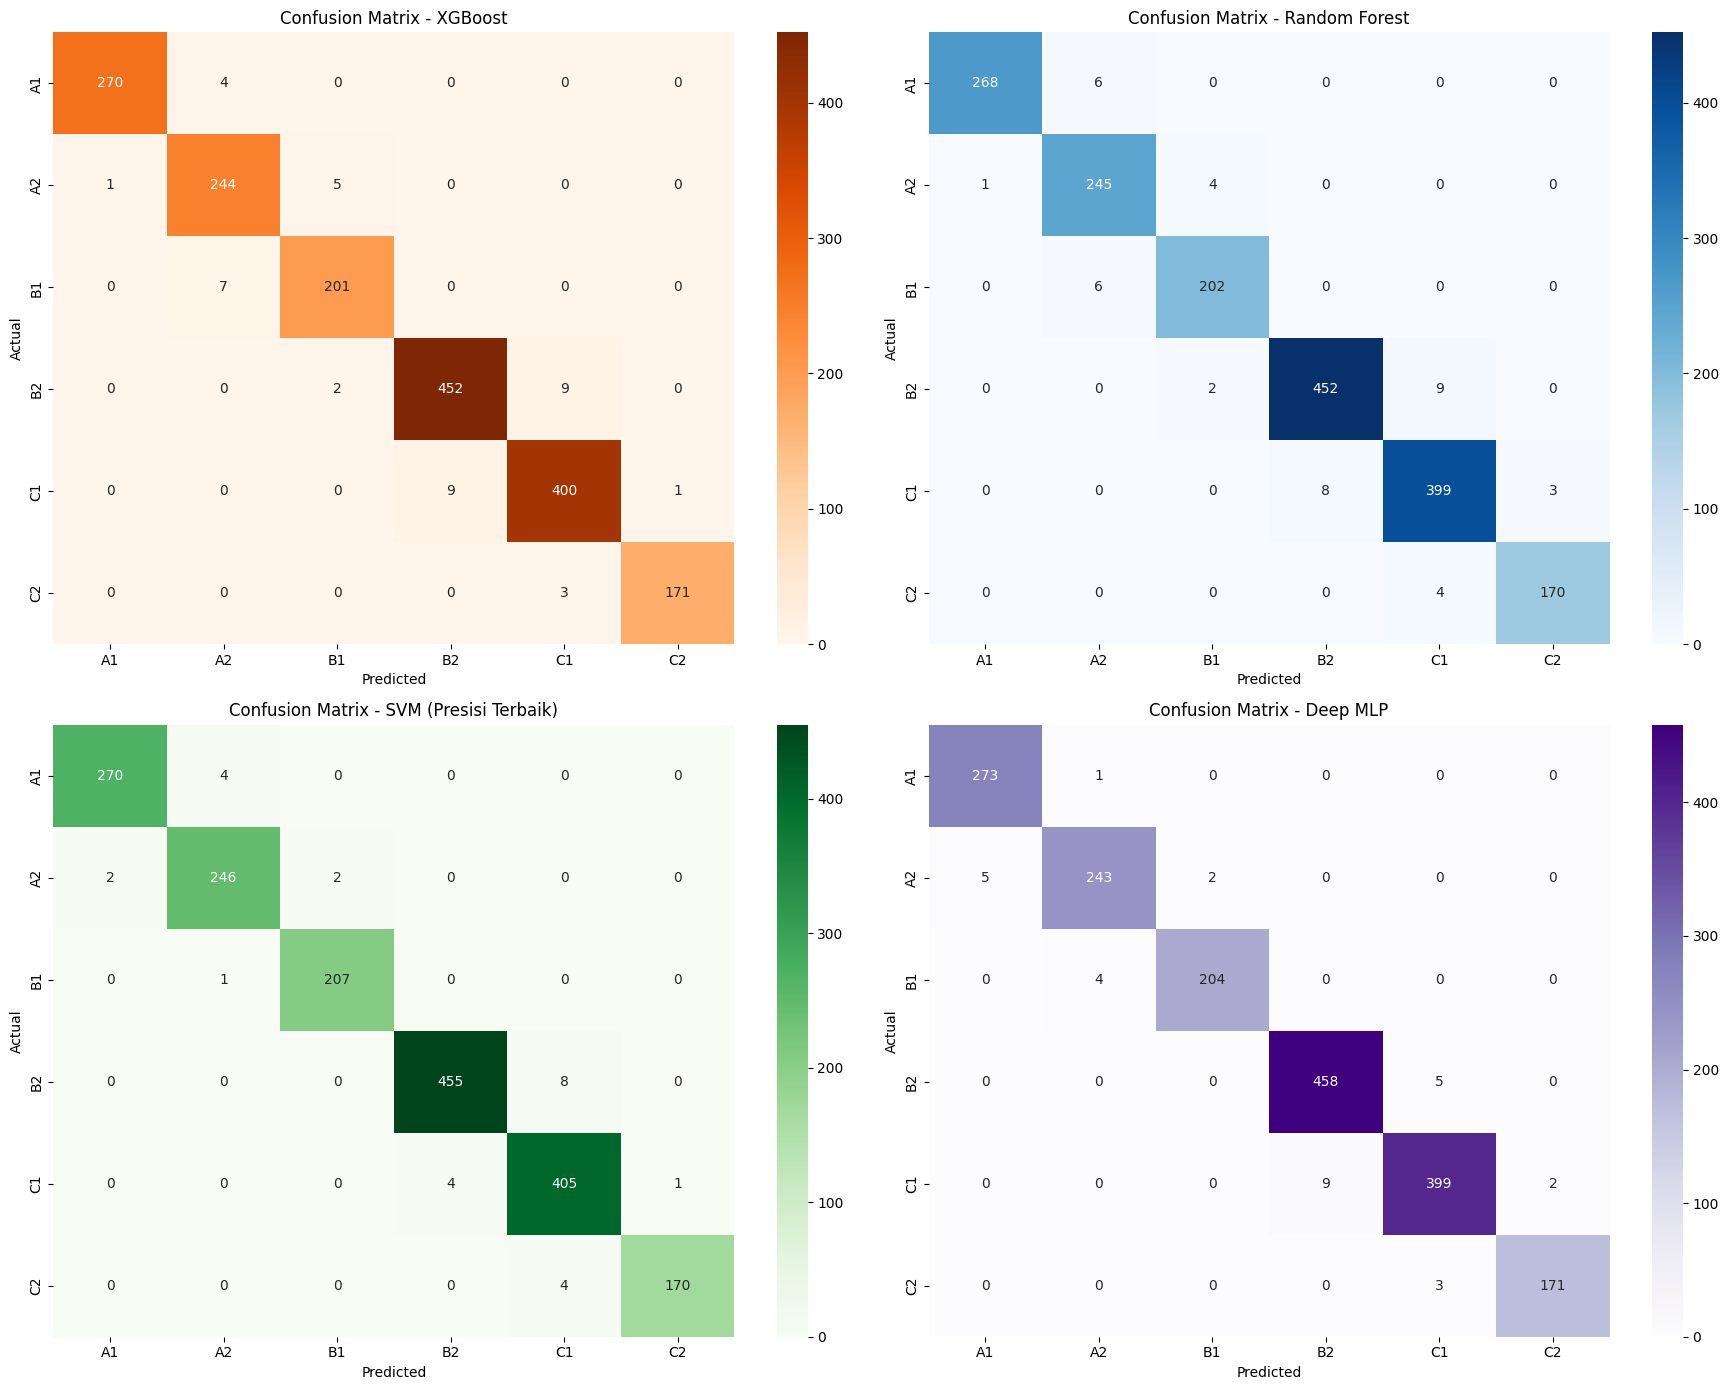

In [55]:
cm_xgb = confusion_matrix(y_test_class, y_pred_xgb)
cm_rf = confusion_matrix(y_test_class, y_pred_rf)
cm_svm = confusion_matrix(y_test_class, y_pred_svm)
cm_mlp = confusion_matrix(y_test_class, y_pred_mlp)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Plot XGBoost
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0,0])
axes[0,0].set_title('Confusion Matrix - XGBoost')
axes[0,0].set_ylabel('Actual')
axes[0,0].set_xlabel('Predicted')

# Plot Random Forest
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0,1])
axes[0,1].set_title('Confusion Matrix - Random Forest')
axes[0,1].set_ylabel('Actual')
axes[0,1].set_xlabel('Predicted')

# Plot SVM
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens', xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1,0])
axes[1,0].set_title('Confusion Matrix - SVM (Presisi Terbaik)')
axes[1,0].set_ylabel('Actual')
axes[1,0].set_xlabel('Predicted')

# Plot MLP
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Purples', xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1,1])
axes[1,1].set_title('Confusion Matrix - Deep MLP')
axes[1,1].set_ylabel('Actual')
axes[1,1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

## 8. Analisis Feature Importance
Perbandingan kontribusi fitur prosodik, linguistik, dan embedding audio pada Random Forest dan XGBoost.

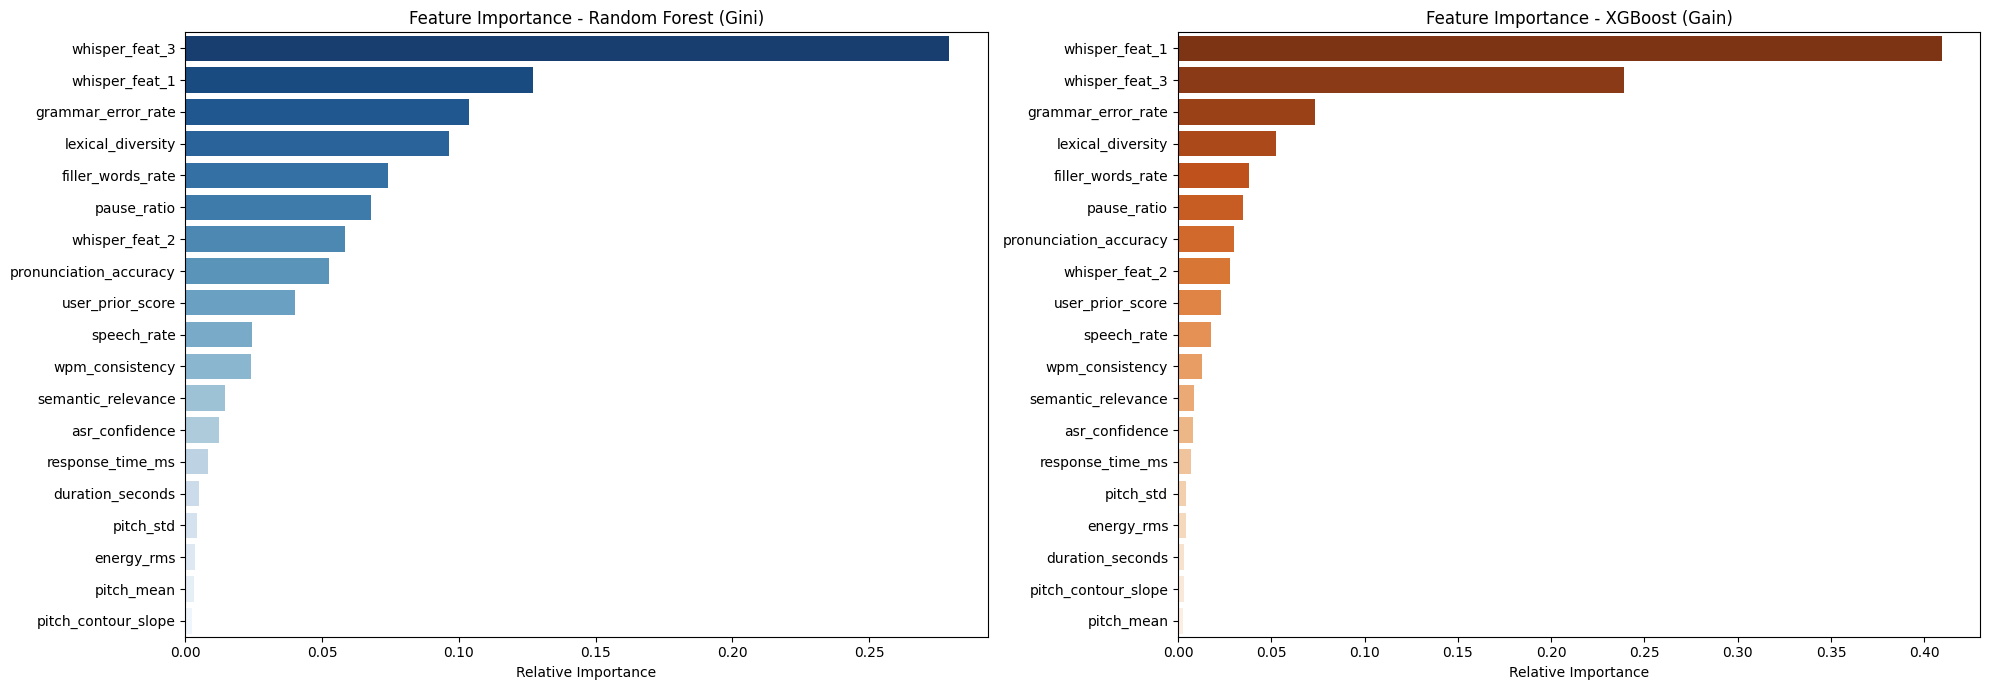

In [56]:
rf_importances = pipeline_rf.named_steps['classifier'].feature_importances_
xgb_importances = pipeline_xgb.named_steps['classifier'].feature_importances_

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Random Forest Feature Importance
indices_rf = np.argsort(rf_importances)[::-1]
sns.barplot(x=rf_importances[indices_rf], y=np.array(numeric_features)[indices_rf], ax=axes[0], palette='Blues_r')
axes[0].set_title('Feature Importance - Random Forest (Gini)')
axes[0].set_xlabel('Relative Importance')

# XGBoost Feature Importance
indices_xgb = np.argsort(xgb_importances)[::-1]
sns.barplot(x=xgb_importances[indices_xgb], y=np.array(numeric_features)[indices_xgb], ax=axes[1], palette='Oranges_r')
axes[1].set_title('Feature Importance - XGBoost (Gain)')
axes[1].set_xlabel('Relative Importance')

plt.tight_layout()
plt.show()

## 9. Modeling Regresi Prosodi (Prosody Similarity Prediction)
Selain menentukan kelas CEFR, kita juga melatih model `RandomForestRegressor` untuk memprediksi skor kemiripan intonasi pembicara terhadap skenario ideal.

In [57]:
from sklearn.pipeline import Pipeline as RegPipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

pipeline_reg = RegPipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

print("Melatih RandomForestRegressor...")
pipeline_reg.fit(X_train, y_train_reg)

# Evaluasi Regresi
y_pred_reg = pipeline_reg.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
print(f"\nRandom Forest Regressor Root Mean Squared Error (RMSE): {rmse:.4f}")

Melatih RandomForestRegressor...

Random Forest Regressor Root Mean Squared Error (RMSE): 8.2704


## 10. Uji Coba Simulasi Penebakan (Inference dengan Classification & Regression)
Simulasi real-time feedback sistem visual kamera menggunakan gabungan model klasifikasi CEFR (Top-2) dan prediksi nilai kecocokan prosodi.

In [58]:
import random

best_class_pipeline = pipeline_svm
best_reg_pipeline = pipeline_reg

# Ambil satu sampel acak dari data testing (speaker baru)
idx = random.randint(0, len(X_test) - 1)
sample = X_test.iloc[[idx]]
actual_label = le.inverse_transform([y_test_class[idx]])[0]
actual_similarity = y_test_reg.iloc[idx]
speaker_sample = df.iloc[test_idx].iloc[idx]['speaker_id']

# 1. Prediksi Klasifikasi
pred_prob = best_class_pipeline.predict_proba(sample)[0]
top_indices = np.argsort(pred_prob)[::-1]

# 2. Prediksi Regresi
pred_similarity = best_reg_pipeline.predict(sample)[0]

print(f"Speaker ID         : {speaker_sample} (Belum pernah dilihat/didengar saat training!)")
print(f"Actual CEFR        : {actual_label}")
print(f"Actual Similarity  : {actual_similarity:.2f}\n")

print("Distribusi Probabilitas Prediksi AI:")
for rank, idx_class in enumerate(top_indices):
    label = le.classes_[idx_class]
    prob = pred_prob[idx_class]
    print(f" Rank {rank+1}: {label} -> {prob*100:.2f}%")

print(f"\nPrediksi Skor Kemiripan Prosodi: {pred_similarity:.2f} (Selisih Error: {abs(pred_similarity - actual_similarity):.2f})")

print("\n-- UI Kamera Feedback (Top-2 & Prosody Analysis) --")
pred_label_1 = le.classes_[top_indices[0]]
pred_label_2 = le.classes_[top_indices[1]]

if actual_label == pred_label_1:
    print(f"AI Visual: [Tersenyum / Mengangguk] -> 'Bagus sekali! Intonasi dan kejelasan bicara Anda sesuai dengan level {pred_label_1}.'")
elif actual_label == pred_label_2:
    print(f"AI Visual: [Mengangguk kecil] -> 'Hampir sempurna! Karakteristik bicara Anda di antara {pred_label_1} dan {pred_label_2}.'")
else:
    print(f"AI Visual: [Mengerutkan dahi] -> 'Coba lagi, perhatikan kejelasan pengucapan kata dan intonasi Anda.'")

Speaker ID         : SPK_133 (Belum pernah dilihat/didengar saat training!)
Actual CEFR        : A1
Actual Similarity  : 49.53

Distribusi Probabilitas Prediksi AI:
 Rank 1: A1 -> 99.91%
 Rank 2: B2 -> 0.03%
 Rank 3: C2 -> 0.02%
 Rank 4: C1 -> 0.02%
 Rank 5: B1 -> 0.01%
 Rank 6: A2 -> 0.00%

Prediksi Skor Kemiripan Prosodi: 50.16 (Selisih Error: 0.64)

-- UI Kamera Feedback (Top-2 & Prosody Analysis) --
AI Visual: [Tersenyum / Mengangguk] -> 'Bagus sekali! Intonasi dan kejelasan bicara Anda sesuai dengan level A1.'
